<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Procesos-estocasticos/blob/main/Serpientes_y_laberinto_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATRIZ FUNDAMENTAL

# SERPIENTES Y ESCALERAS

**Nombre: Karla Michelle Soriano Sánchez**

**Objetivo** : Analizar el juego de serpientes y escaleras utilizando cadenas de Markov absorbentes y simulación Monte Carlo, con el propósito de determinar el número promedio de tiradas necesarias para finalizar el juego.

Posteriormente, se compararán los resultados analíticos con los resultados experimentales obtenidos mediante simulación.


**Instrucciones**:  Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

Resolver a detalle.

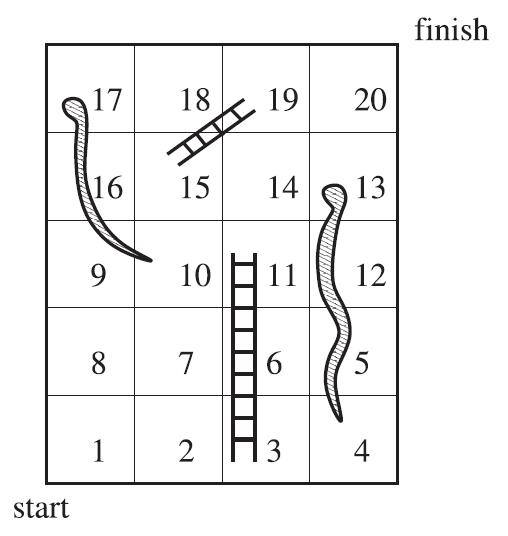




El juego de serpientes y escaleras puede modelarse mediante una cadena de Markov, ya que la posición futura del jugador depende únicamente de la casilla en la que se encuentra actualmente y del resultado obtenido al lanzar el dado.

En este modelo, cada casilla del tablero representa un estado del sistema y las probabilidades de transición se determinan considerando todos los posibles resultados del dado.

Además, debido a que el juego termina cuando el jugador alcanza la última casilla, el sistema corresponde a una cadena de Markov absorbente.

En esta práctica se construirá la matriz de transición del juego, posteriormente se obtendrá la matriz fundamental y finalmente se realizará una simulación Monte Carlo para validar los resultados obtenidos analíticamente.


## SOLUCION ANALITICA

### Descripción del tablero

El tablero del juego está formado por $20$ casillas numeradas del $1$ al $20$.

La casilla $20$ corresponde al estado absorbente, ya que una vez que el jugador llega a dicha casilla el juego termina.

Las reglas especiales del tablero son:

* Escaleras: Las escaleras permiten avanzar automáticamente a una casilla superior:

$$
3 \longrightarrow 11
$$

$$
15 \longrightarrow 19
$$

* Serpientes: Las serpientes obligan al jugador a retroceder a una casilla inferior:

$$
13 \longrightarrow 4
$$

$$
17 \longrightarrow 10
$$



### Construcción de la matriz de transición

Sea

$$
P=(P_{ij})
$$

la matriz de transición asociada al juego.

Cada entrada $P_{ij}$ representa la probabilidad de pasar de la casilla $i$ a la casilla $j$ en un solo movimiento.

Matemáticamente:

$$
P_{ij}=P(X_{n+1}=j \mid X_n=i)
$$

donde:

- $X_n$ representa la posición del jugador en el paso $n$.
- $X_{n+1}$ representa la posición después de realizar un lanzamiento.


El juego puede modelarse mediante una cadena de Markov absorbente debido a que:

- El siguiente movimiento depende únicamente de la posición actual.
- Existe un estado absorbente (casilla \(20\)).
- Las probabilidades de transición permanecen constantes.


### Probabilidades de transición

Para cada casilla transitoria \(i\), los posibles resultados del dado son:

$$
1,2,3,4,5,6
$$

Como el dado es justo, cada resultado ocurre con probabilidad:

$$
\frac{1}{6}
$$

Si el jugador se encuentra en la casilla \(i\), entonces el movimiento tentativo se calcula mediante:

$$
\text{destino}_{\text{tentativo}}
=
i+\text{dado}
$$

Posteriormente se revisan las reglas especiales del tablero.

- Si el jugador cae en una escalera, avanza automáticamente.
- Si el jugador cae en una serpiente, retrocede automáticamente.

Además, si el movimiento supera la casilla \(20\), el jugador pasa directamente al estado absorbente:

$$
j=20
$$



### Procedimiento para construir la matriz

La construcción de la matriz de transición se realiza siguiendo los pasos:

1. Lanzar el dado.
2. Avanzar el número de casillas indicado.
3. Verificar si la nueva casilla contiene una serpiente o una escalera.
4. Aplicar automáticamente el salto correspondiente.
5. Registrar la probabilidad de transición obtenida.

Repitiendo este procedimiento para todas las casillas del tablero se obtiene la matriz de transición completa.


### Clasificación de estados

La matriz de transición presenta:

- Estados transitorios:

$$
1,2,3,\dots,19
$$

ya que desde estas casillas todavía es posible continuar jugando.

- Estado absorbente:

$$
20
$$

porque una vez alcanzado dicho estado, el proceso termina y ya no es posible salir de él.

Por esta razón:

$$
P_{20,20}=1
$$

lo cual indica que el sistema permanece permanentemente en la casilla final.

In [73]:
import numpy as np
import sympy as sp

In [74]:
def matriz_transicion():
  #configuracion del tablero del juego (casillas )
    n = 20

    #Numero de caras del dado
    dado = 6

    # Saltos: escaleras y serpientes
    salto = {3: 11, 15: 19, 13: 5, 17: 7}


    #inicializamos la matriz
    P = np.zeros((n, n))
    P[n-1, n-1] = 1  # estado absorbente


    #construccion de probabilidades
    for i in range(1, n):
        for k in range(1, dado + 1):
            pos = min(i + k, n)          # si se pasa → 20
            pos = salto.get(pos, pos)    # aplicar salto si existe
            P[i-1, pos-1] += 1/dado

    return P

In [75]:
# imprimir la matriz
P = matriz_transicion()
print("Matriz de transición:")
sp.Matrix(P)

Matriz de transición:


Matrix([
[0.0, 0.166666666666667, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0,               0.0, 0.1666

In [76]:
#             1,   2, 3,   4,   5,   6,   7,   8,   9,  10,  11, 12, 13, 14, 15, 16, 17, 18, 19, 20
P=sp.Matrix([[0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0, 1/6, 0,1/6,  0,1/6,  0,  0,1/6, 0],#3_11
             [0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,  0,  0,  0,  0,  0,  0,  0,  0, 0],
             [0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,  0,  0,  0,  0,  0,  0, 0],#6
             #7
             [0,   0, 0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,  0,  0,  0,  0,  0,  0, 0],
              #8
             [0,   0, 0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0,1/6,  0,  0,  0,  0,  0, 0],
              #9
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0,1/6,  0,  0,  0,  0,1/6, 0],
              #10
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0,   0, 1/6, 1/6, 0,1/6,  0,1/6,  0,  0,1/6,  0],

              #11
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0, 1/6, 0,1/6,  0,1/6,  0,  0,1/6, 0],
              #12
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,1/6,  0,1/6,  0,1/6,1/6, 0],
              #13 es 4
             [0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,  0,  0,  0,  0,  0,  0, 0],
              #14
             [0,   0, 0,   0,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,  0,  0,1/6,  0,1/6,2/6,1/6],
              #15
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1],
              #16
             [0,   0, 0,   0,   0,   0,   0,   0,   0, 1/6,   0,   0, 0,  0,  0,  0,  0,1/6,1/6,3/6],
              #17 es 10
             [0,   0, 0, 1/6,   0,   0,   0,   0,   0,   0, 1/6, 1/6, 0,1/6,  0,1/6,  0,  0,1/6,  0],
              #18
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,1/6,5/6],
              #19
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1],
              #20
             [0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 0,  0,  0,  0,  0,  0,  0,  1]])
#             1,   2, 3,   4,   5,   6,   7,   8,   9,  10,  11,  12, 13, 14, 15, 16, 17, 18, 19, 20


### Interpretación de la matriz de transición

La matriz obtenida es de tamaño:

$$
20 \times 20
$$

Cada fila representa el estado actual del jugador y cada columna representa el estado al que puede transitar después de una tirada.

Por ejemplo:

$$
P_{ij}
$$

representa la probabilidad de pasar de la casilla \(i\) a la casilla \(j\).

La última fila corresponde al estado absorbente:

$$
P_{20,20}=1
$$

ya que una vez alcanzada la casilla 20 el juego finaliza y el proceso permanece permanentemente en dicho estado.

### Forma canónica de la matriz


Una vez construida la matriz de transición \(P\), procedemos a escribirla en su forma canónica.

La forma canónica de una cadena de Markov absorbente organiza los estados de manera que primero aparecen los estados transitorios y al final los estados absorbentes.


En este problema:

- Estados transitorios:

$$
1,2,3,\dots,19
$$

- Estado absorbente:

$$
20
$$

Por esta razón, la matriz puede escribirse en la forma:

$$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- $Q$: contiene las probabilidades de transición entre estados transitorios.
- $R$: contiene las probabilidades de pasar de un estado transitorio al estado absorbente.
- $I$: corresponde a la matriz identidad asociada al estado absorbente.
- $0$: representa una matriz de ceros.

En este problema:

- Las casillas 1 a 19 son estados transitorios.
- La casilla 20 es el estado absorbente.


Para simplificar el procedimiento utilizamos una función que transforma automáticamente la matriz $P$ a su forma canónica.




In [77]:
import sympy as sp

def canonica(P):
    """
    Calcula la descomposición canónica de una matriz de transición P.

    Parámetros:
    P : matriz de transición (SymPy)

    Retorna:
    - Matriz reorganizada en forma canónica
    """

    n = P.shape[0]

    # --------------------------------------------------
    # Paso 1: Función de alcanzabilidad R(i)
    # --------------------------------------------------
    # Devuelve los estados alcanzables desde i
    def R(i):
        s = {i}
        stack = [i]

        while stack:
            u = stack.pop()
            for v in range(n):
                if P[u,v] != 0 and v not in s:
                    s.add(v)
                    stack.append(v)

        return s

    # --------------------------------------------------
    # Paso 2: Encontrar clases de comunicación
    # --------------------------------------------------
    no = set(range(n))
    clases = []

    while no:
        i = next(iter(no))
        Ri = R(i)

        # Estados que se comunican con i
        c = {j for j in Ri if i in R(j)}

        clases.append(c)
        no -= c

    print("Clases de comunicación:")
    for c in clases:
        print(c)

    # --------------------------------------------------
    # Paso 3: Identificar clases cerradas (recurrentes)
    # --------------------------------------------------
    T = set(range(n))
    for c in clases:
        if all(P[i,j]==0 or j in c for i in c for j in range(n)):
            T -= c

    T = list(T)
    Rr = [i for c in clases for i in c if i not in T]

    orden = T + Rr
    return P.extract(orden, orden)

    # --------------------------------------------------
    # Paso 4: Estados transitorios
    # --------------------------------------------------
    T = list(T)  # recurrentes
    Rr = [i for c in clases for i in c if i not in T]

    print("\nEstados recurrentes:", T)
    print("Estados transitorios:", Rr)

    # --------------------------------------------------
    # Paso 5: Orden final
    # --------------------------------------------------
    orden = T + Rr

    print("\nOrden de estados:", orden)

    # --------------------------------------------------
    # Paso 6: Matriz canónica
    # --------------------------------------------------
    P_can = P.extract(orden, orden)

    print("\nMatriz en forma canónica:")
    sp.pprint(P_can)

    return P_can

Aplicamos la función a la matriz de transición:

In [78]:
canonica (P)

Clases de comunicación:
{0}
{1}
{2}
{3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15}
{12}
{14}
{16}
{17}
{18}
{19}


Matrix([
[0, 0.166666666666667, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667,                 0,                 0,                 0,                 0,                 0, 0.166666666666667,                 0, 0.166666666666667, 0, 0.166666666666667, 0, 0.166666666666667, 0,                 0, 0.166666666666667,                 0],
[0,                 0, 0,                 0, 0.166666666666667, 0.166666666666667, 0.

La matriz obtenida corresponde a la representación canónica de la cadena de Markov absorbente.

A continuación extraemos la submatriz $Q$, la cual contiene únicamente las probabilidades de transición entre estados transitorios.

En este caso:

$$
Q=P_c(1:19,1:19)
$$

Posteriormente construimos la matriz identidad $I$ de dimensión $19 \times 19$,  ya que existen $19$ estados transitorios.

In [79]:
# Extraer submatriz Q
Q = P[:19,:19]

print("Submatriz Q:")

Q

Submatriz Q:


Matrix([
[0, 0.166666666666667, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,                 0,                 0, 0.166666666666667,                 0, 0,                 0, 0,                 0, 0,                 0,                 0],
[0,                 0, 0, 0.166666666666667,                 0,                 0,                 0,                 0,                 0, 0.166666666666667,                 0, 0.166666666666667, 0, 0.166666666666667, 0, 0.166666666666667, 0,                 0, 0.166666666666667],
[0,                 0, 0,                 0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.

La matriz:

$$
I-Q
$$

es fundamental en el estudio de cadenas absorbentes, ya que permite calcular la matriz fundamental del sistema.

In [80]:
I=np.identity(19)
I-Q

Matrix([
[1.0, -0.166666666666667,   0, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667,                  0,                  0,                  0, -0.166666666666667,                  0,   0,                  0,   0,                  0,   0,                  0,                  0],
[  0,                1.0,   0, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667, -0.166666666666667,                  0,                  0, -0.166666666666667,                  0,   0,                  0,   0,                  0,   0,                  0,                  0],
[  0,                  0, 1.0, -0.166666666666667,                  0,                  0,                  0,                  0,                  0, -0.166666666666667,                  0, -0.166666666666667,   0, -0.166666666666667,   0, -0.166666666666667,   0,                  0, -0.166666666666667],
[  0,                  0,   0,                1.0, -0.166666666666667,

### Matriz fundamental

La matriz fundamental se define mediante:

$$
N=(I-Q)^{-1}
$$

Esta matriz es una de las herramientas más importantes en cadenas de Markov absorbentes.

La interpretación probabilística de $N$ es la siguiente:

- Cada entrada $N_{ij}$representa el número esperado de veces que el proceso visitará el estado $j$comenzando desde el estado $i$, antes de ser absorbido.

Además, la suma de cada fila proporciona el número esperado de pasos necesarios para llegar al estado absorbente.

In [81]:
N=(I-Q)**(-1)
N

Matrix([
[1.0, 0.166666666666667,   0,   0.66897572306483,  0.305940398288583,  0.356930464670013,  0.416418875448349,   0.31915535468974,  0.344570136026919, 0.706598709071859,  0.602713434143688,  0.457731162341761,   0, 0.405128132712328,   0, 0.362028573044939,   0, 0.204147978016505, 0.581341043011721],
[  0,               1.0,   0,  0.647471733083607,  0.274578622180601,  0.320341725877368,  0.373732013523596,  0.436020682444195,  0.342024129518228, 0.700619124603555,  0.574552716357924,  0.457881732054144,   0, 0.418516397496341,   0, 0.358594995085327,   0, 0.205832187439302, 0.579422946675194],
[  0,                 0, 1.0,  0.390190673625065, 0.0650317789375108, 0.0758704087604293, 0.0885154768871675,  0.103268056368362,  0.120479399096422, 0.521199266353474,  0.162394064400561,  0.345287778644403,   0,  0.37543809414387,   0, 0.400719867257051,   0, 0.186907623340887, 0.581310697896756],
[  0,                 0,   0,    1.4756020316059,  0.245933671934317,  0.286922617256703

Una vez obtenida la matriz fundamental, calculamos el número esperado de tiradas necesarias para finalizar el juego.

Como el jugador inicia en la casilla $1$, debemos sumar los elementos del primer renglón de la matriz $N$ .

Esto se debe a que dicho renglón representa el número esperado de visitas a cada estado transitorio comenzando desde la casilla inicial.

In [82]:
a = sum(N[0,0:19])
a

6.89834665119790

El resultado obtenido es:

$$
a \approx 6.8983
$$

Por lo tanto, el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras, comenzando desde la casilla \(1\), es aproximadamente:

$$
6.89 \text{ tiradas}
$$

Este valor representa el tiempo esperado de absorción de la cadena de Markov.

## SOLUCIÓN POR SIMULACIÓN MONTE CARLO

Una vez obtenido el resultado analítico mediante la matriz fundamental, realizamos una simulación Monte Carlo con el propósito de validar experimentalmente dicho resultado.

La idea principal de la simulación consiste en reproducir muchas veces el comportamiento del jugador dentro del tablero.

En cada simulación se realiza el siguiente procedimiento:

1. El jugador inicia en la casilla \(1\).
2. Se lanza un dado justo de seis caras.
3. El jugador avanza el número de casillas obtenido.
4. Si el jugador cae en una serpiente o escalera, se aplica automáticamente el salto correspondiente.
5. El proceso continúa hasta alcanzar la casilla $20$.

Las reglas especiales del tablero son:

*  Escaleras

$$
3 \longrightarrow 11
$$

$$
15 \longrightarrow 19
$$

* Serpientes

$$
13 \longrightarrow 4
$$

$$
17 \longrightarrow 10
$$

Repitiendo este experimento una gran cantidad de veces es posible aproximar el número esperado de tiradas necesarias para terminar el juego.

De acuerdo con la Ley de los Grandes Números, el promedio obtenido mediante simulación debe aproximarse al valor esperado calculado analíticamente mediante la matriz fundamental.

### Función de simulación

Definimos ahora una función que simula una partida completa del juego.

La función:

- inicia en la casilla $1$,
- lanza el dado repetidamente,
- aplica las reglas especiales del tablero,
- y contabiliza el número total de tiradas necesarias para llegar a la casilla $20$.

In [83]:
import random as r

def serpi():

    # Casilla inicial
    j = 1

    # Contador de tiradas
    tiradas = 0

    # Diccionario de serpientes y escaleras
    salto = {
        3:11,
        15:19,
        13:4,
        17:10
    }

    # El juego continúa hasta llegar a la casilla 20
    while j < 20:

        # Lanzamiento del dado
        a = r.randrange(1,7)

        # Contabilizar tirada
        tiradas += 1

        # Movimiento del jugador
        j += a

        # Si excede la casilla 20,
        # se considera absorbido
        j = min(j,20)

        # Aplicar serpiente o escalera
        j = salto.get(j,j)

    return tiradas

La siguiente instrucción ejecuta una partida individual del juego y devuelve el número de tiradas necesarias para finalizarla.

In [84]:
serpi()

17

Para obtener una aproximación confiable del valor esperado, repetimos el experimento múltiples veces.

En cada simulación se registra el número de tiradas necesarias para llegar a la casilla final.

In [85]:
# Número de simulaciones

N = 10000

# Lista para guardar resultados
resultados = []

for i in range(N):

    resultados.append(serpi())

### Cálculo del promedio experimental

El promedio de las simulaciones proporciona una aproximación experimental del tiempo esperado de absorción de la cadena de Markov.

In [86]:
promedio = np.mean(resultados)

mediana = np.median(resultados)

print(f"Promedio de tiradas: {promedio:.2f}")

print(f"Mediana: {mediana:.0f}")

Promedio de tiradas: 6.91
Mediana: 6


### Interpretación del resultado

El valor promedio obtenido mediante simulación representa el número esperado de tiradas necesarias para terminar el juego comenzando desde la casilla inicial.

Este resultado debe ser cercano al valor obtenido analíticamente mediante la matriz fundamental.

### Histograma de resultados

Finalmente representamos gráficamente la distribución del número de tiradas necesarias para completar el juego.

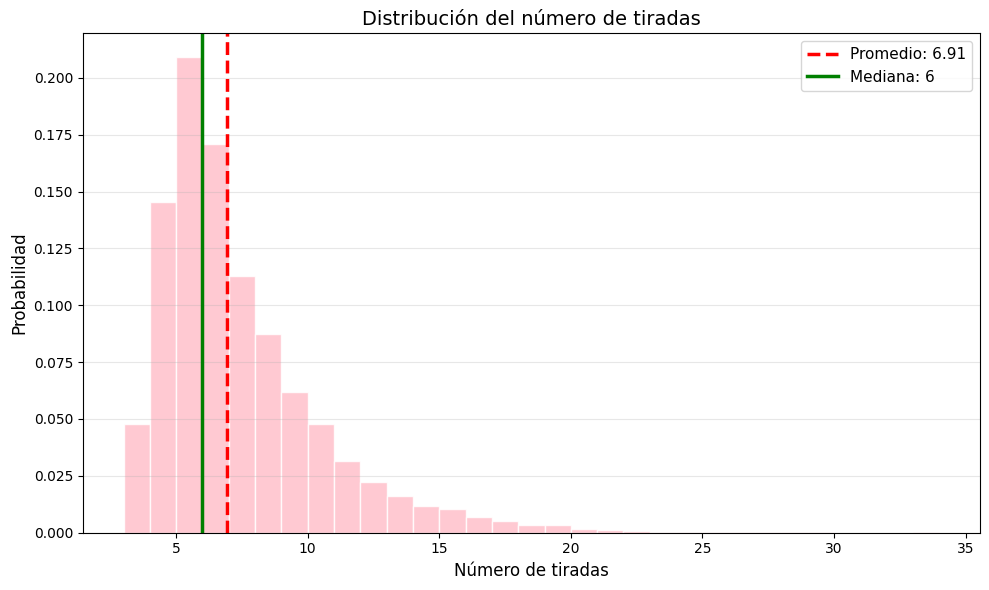

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    resultados,
    bins=range(min(resultados), max(resultados)+2),
    edgecolor='white',
    color='pink',
    alpha=0.85,
    density=True
)

# Línea del promedio
plt.axvline(
    promedio,
    color='red',
    linestyle='--',
    linewidth=2.5,
    label=f'Promedio: {promedio:.2f}'
)

# Línea de la mediana
plt.axvline(
    mediana,
    color='green',
    linestyle='-',
    linewidth=2.5,
    label=f'Mediana: {mediana:.0f}'
)

plt.xlabel("Número de tiradas",fontsize=12)

plt.ylabel("Probabilidad",fontsize=12)

plt.title(
    "Distribución del número de tiradas",
    fontsize=14
)

plt.legend(fontsize=11)

plt.grid(axis='y',alpha=0.3)

plt.tight_layout()

plt.show()

### Comparación entre teoría y simulación

El resultado obtenido mediante simulación Monte Carlo debe aproximarse al valor obtenido analíticamente utilizando la matriz fundamental.

Esto ocurre debido a la Ley de los Grandes Números, la cual establece que conforme aumenta el número de simulaciones, el promedio experimental converge al valor esperado teórico.

Por lo tanto, la simulación permite validar experimentalmente el modelo probabilístico construido mediante cadenas de Markov absorbentes.

# RATÓN Y COMIDA

**Objetivo** : Analizar el movimiento aleatorio de un ratón sobre un tablero mediante cadenas de Markov absorbentes, con el propósito de calcular la probabilidad de que el ratón, iniciando en la casilla $0$, alcance la comida antes de llegar a la casilla de descarga eléctrica.

Además, se utilizará la forma canónica de la matriz de transición y la matriz fundamental para determinar las probabilidades de absorción del sistema.


**Introducción** : Las cadenas de Markov permiten modelar sistemas probabilísticos donde el estado futuro depende únicamente del estado actual.

En este problema, el movimiento del ratón puede representarse mediante una cadena de Markov, ya que en cada paso el ratón se desplaza aleatoriamente hacia alguna casilla vecina del tablero siguiendo probabilidades definidas.

El tablero contiene dos estados especiales:

- La casilla \(7\), que representa la comida.
- La casilla \(8\), que representa una descarga eléctrica *shock*.

Una vez que el ratón alcanza cualquiera de estas dos casillas, el proceso termina. Por esta razón, dichos estados se consideran absorbentes.

El objetivo principal consiste en calcular la probabilidad de que el ratón logre alcanzar la comida antes de llegar al estado de descarga eléctrica.

Para ello se utilizará la teoría de cadenas de Markov absorbentes, la forma canónica de la matriz de transición y la matriz fundamental:

$$
F=(I-Q)^{-1}
$$

la cual permite calcular probabilidades de absorción dentro del sistema

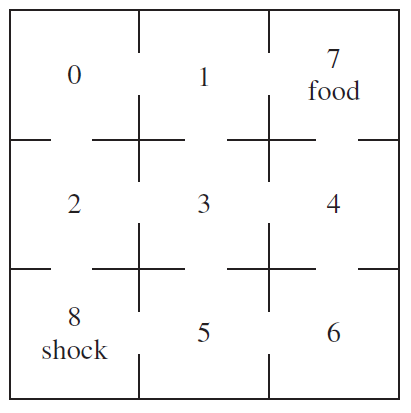

### Descripción del problema

El tablero está formado por las casillas:

$$
0,1,2,3,4,5,6,7,8
$$

Asi que el espacio de estados esta dado por:


$$
S=\{0,1,2,3,4,5,6,7,8\}
$$
donde:

- La casilla \(7\) representa el estado de comida *food*.
- La casilla \(8\) representa el estado de descarga eléctrica*shock*.

El ratón inicia en la casilla:$
0$ y en cada movimiento puede desplazarse únicamente hacia casillas vecinas conectadas mediante las líneas del tablero.

Cada movimiento posible se considera equiprobable.

Los estados absorbentes son:

$$
7 \quad \text{(food)}
$$

y

$$
8 \quad \text{(shock)}
$$


$$
F=\{7,8\}
$$
ya que una vez alcanzados el proceso termina.

Mientras que los estados restantes:

$$
T=\{0,1,2,3,4,5,6\}
$$

son estados transitorios. Se supondrá que todos los movimientos posibles desde una casilla tienen la misma probabilidad.





### Modelado mediante cadenas de Markov

La dinámica del sistema puede representarse mediante una cadena de Markov absorbente.

Observemos que:

- Los estados \(0,1,2,3,4,5,6\) son transitorios.
- Los estados \(7\) y \(8\) son absorbentes.

La matriz de transición del sistema se denota por:

$$
P=(P_{ij})
$$

donde:

$$
P_{ij}=P(X_{n+1}=j \mid X_n=i)
$$

representa la probabilidad de pasar del estado \(i\) al estado \(j\)



In [88]:
import numpy as np
import sympy as sp
from sympy import Matrix

### cosntrucción de la matriz de trancisión:
Sea:

$$
P_{ij}=P(X_{n+1}=j\mid X_n=i)
$$

la probabilidad de pasar del estado \(i\) al estado \(j\).

Con base en las conexiones del laberinto se construye la siguiente matriz de transición:

In [89]:
          #    0      1,   2,   3,   4,   5,   6,   7,   8
P = sp.Matrix([[0  , 0.5, 0.5,   0,   0,   0,   0,   0,   0],
              [1/3,   0,   0, 1/3,   0,   0,   0, 1/3,   0],
              [1/3,   0,   0, 1/3,   0,   0,   0,   0, 1/3],
              [  0, 1/4, 1/4,   0, 1/4, 1/4,   0,   0,   0],
              [  0,   0,   0, 1/3,   0,   0, 1/3, 1/3,   0],
              [  0,   0,   0, 1/3,   0,   0, 1/3,   0, 1/3],
              [  0,   0,   0,   0, 0.5, 0.5,   0,   0,   0],
              [  0,   0,   0,   0,   0,   0,   0,   1,   0],
              [  0,   0,   0,   0,   0,   0,   0,   0,   1]])



Matriz de transición del laberinto de la rata con las respectivas probabilidades de ir de un estado a otro

### Forma canónica absorbente

Para simplificar el proceso de reorganización de la matriz se utiliza la función `canonica(P)`, la cual permite transformar automáticamente la matriz de transición a la forma canónica absorbente:

$$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- \(Q\) contiene las probabilidades de transición entre estados transitorios,
- \(R\) contiene las probabilidades de transición de estados transitorios hacia estados absorbentes,
- \(I\) corresponde a la matriz identidad asociada a los estados absorbentes.

In [90]:
canonica(P)

Clases de comunicación:
{0, 1, 2, 3, 4, 5, 6}
{7}
{8}


Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0,                 0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0,                 0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333, 0.333333333333333,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333,                 0, 0.333333333333333],
[                0,    0,    0,                 0,  0.5,  0.5,                 0,                 0,                 0],
[                0,    0,    0,                 0,    0,    0,                 0,                 1,                 0],
[                0,    

### Matriz fundamental

La matriz fundamental se define mediante:

$$
F=(I-Q)^{-1}
$$

donde \(I\) es la matriz identidad de dimensión igual a la de \(Q\).

Esta matriz permite calcular el comportamiento esperado del sistema antes de ser absorbido.

In [91]:
Q = P[0:7,0:7]
Q

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333],
[                0,    0,    0,                 0,  0.5,  0.5,                 0]])

In [92]:
I= sp.eye(7)
I

Matrix([
[1, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 1]])

In [93]:
I-Q

Matrix([
[                 1,  -0.5,  -0.5,                  0,     0,     0,                  0],
[-0.333333333333333,     1,     0, -0.333333333333333,     0,     0,                  0],
[-0.333333333333333,     0,     1, -0.333333333333333,     0,     0,                  0],
[                 0, -0.25, -0.25,                  1, -0.25, -0.25,                  0],
[                 0,     0,     0, -0.333333333333333,     1,     0, -0.333333333333333],
[                 0,     0,     0, -0.333333333333333,     0,     1, -0.333333333333333],
[                 0,     0,     0,                  0,  -0.5,  -0.5,                  1]])

In [94]:
F = (I-Q).inv()
F

Matrix([
[1.75, 1.125, 1.125, 1.0, 0.375, 0.375, 0.25],
[0.75, 1.625, 0.625, 1.0, 0.375, 0.375, 0.25],
[0.75, 0.625, 1.625, 1.0, 0.375, 0.375, 0.25],
[ 0.5,  0.75,  0.75, 2.0,  0.75,  0.75,  0.5],
[0.25, 0.375, 0.375, 1.0, 1.625, 0.625, 0.75],
[0.25, 0.375, 0.375, 1.0, 0.625, 1.625, 0.75],
[0.25, 0.375, 0.375, 1.0, 1.125, 1.125, 1.75]])

### Probabilidades de absorción

Las probabilidades de absorción se obtienen mediante:

$$
B=F\cdot R
$$

donde cada entrada:

$$
B_{ij}
$$

representa la probabilidad de terminar en el absorbente \(j\), iniciando desde el estado transitorio \(i\).

Es la matriz superior derecha a excepción de los estados transitorios de $Q$
 y el estado absorbente


In [95]:
R = P[0:7,7:9]
R

Matrix([
[                0,                 0],
[0.333333333333333,                 0],
[                0, 0.333333333333333],
[                0,                 0],
[0.333333333333333,                 0],
[                0, 0.333333333333333],
[                0,                 0]])

Al realizar el producto se obtienen las probailidaades parq uqe alcance la comida iniciando en $0$

In [96]:
B=F*R
B

Matrix([
[              0.5,               0.5],
[0.666666666666667, 0.333333333333333],
[0.333333333333333, 0.666666666666667],
[              0.5,               0.5],
[0.666666666666667, 0.333333333333333],
[0.333333333333333, 0.666666666666667],
[              0.5,               0.5]])

La probabilidad de que el ratón alcance la comida iniciando desde el estado $0$ corresponde a la entrada:

$$
B_{0,0}
$$

ya que:

- la fila \(0\) representa el estado inicial \(0\),
- y la columna \(0\) representa el absorbente asociado a la comida (\(7\)).

In [97]:
B[0,0]

0.500000000000000

$$
B_{0,0}=0.5
$$

Por lo tanto:

$$
P(\text{llegar a food desde }0)=0.5
$$

Es decir, el ratón tiene una probabilidad del $50\%$ de alcanzar la comida iniciando desde la casilla $0$.

## Solución por simulación


Con el objetivo de verificar experimentalmente el resultado analítico obtenido mediante la matriz fundamental, se realiza una simulación del movimiento del ratón dentro del laberinto.

La idea consiste en repetir muchas veces el recorrido del ratón iniciando desde el estado \(0\), permitiendo que en cada paso el movimiento se elija aleatoriamente entre las conexiones disponibles.

El proceso termina cuando el ratón alcanza alguno de los estados absorbentes:

$$
7 \quad \text{(food)}
$$

o bien:

$$
8 \quad \text{(shock)}
$$

En cada simulación se registra si el ratón logró alcanzar la comida.

Finalmente, la probabilidad experimental se aproxima mediante:

$$
P(\text{food}) \approx
\frac{\text{Número de veces que llega a food}}
{\text{Número total de simulaciones}}
$$

De esta manera se compara el resultado experimental con la probabilidad analítica obtenida anteriormente.

In [98]:
from os import chmod
import random as r


La siguiente función simula una trayectoria de la cadena de Markov.

La función recibe:

- la matriz de transición \(P\),
- el número máximo de pasos \(n\),
- y el estado inicial \(x_0\).

Durante el proceso se almacena la trayectoria recorrida y se verifica si el ratón alcanza alguno de los estados absorbentes.

In [99]:
def markov(a, P, n,x0):
    m = len(P)          # número de estados
    S = list(range(m))  # estados en lista

    cadena = [x0]

    csiete=0
    cocho=0

    for i in range(n):
        p = P[x0] # renglón de transición
        x1 = r.choices(S, weights=p, k=1)[0]

        cadena.append(x1)
        if x1 == 7:
            csiete += 1
            break
        if x1 == 8:
            cocho += 1
            break
        x0 = x1

    return cadena, csiete, cocho

Ahora se define una función que repite múltiples veces la simulación anterior. La idea es aproximar experimentalmente la probabilidad de absorción en el estado:

$$
7
$$

utilizando el método de Monte Carlo.

En cada experimento se registra si el ratón logró alcanzar la comida y posteriormente se calcula la frecuencia relativa.

In [100]:
def probabilidad(n,a,P):
  contsiete=0
  contocho=0
  for i in range(n):
    c,s,o=markov(a, P, n,x0)
    if s == 1:
       contsiete +=1
    if o == 1:
       contocho +=1
  return contsiete/n

A continuación se define la matriz de transición del laberinto y se realizan múltiples simulaciones iniciando desde el estado:

$$
x_0 = 0
$$

Con ello se obtiene una aproximación experimental de la probabilidad de llegar a la comida.

In [101]:
b = [1, 0, 0, 0, 0, 0, 0, 0, 0]


#    0      1,   2,   3,   4,   5,   6,   7,   8
P =([0  , 0.5, 0.5,   0,   0,   0,   0,   0,   0],
    [1/3,   0,   0, 1/3,   0,   0,   0, 1/3,   0],
    [1/3,   0,   0, 1/3,   0,   0,   0,   0, 1/3],
    [  0, 1/4, 1/4,   0, 1/4, 1/4,   0,   0,   0],
    [  0,   0,   0, 1/3,   0,   0, 1/3, 1/3,   0],
    [  0,   0,   0, 1/3,   0,   0, 1/3,   0, 1/3],
    [  0,   0,   0,   0, 0.5, 0.5,   0,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   1,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0,   1])



In [102]:
n=10000
x0=0

probabilidad(n,a,P)

0.5039

Después de realizar $10000$ somulaciones iniciando desde el estado $0$ se obtuvo experimentalmente una probabilñidad aproximada de
$$0.539$$

Este resultado es muy cercano al valor analítico obtenido anteriormente mediante:

$$
B = F\cdot R
$$

donde:

$$
B_{0,0}=0.5
$$

Por lo tanto, la simulación confirma que el ratón tiene aproximadamente un \(50\%\) de probabilidad de alcanzar la comida iniciando desde la casilla $0$.